# Screenshot

```python
# by default, takes a screenshot of the viewport only (visible window)
page.screenshot(path="viewport_test_get_started_visits_docs.jpg")

# full_page=True, takes full page screenshot
page.screenshot(path="fullpage_test_get_started_visits_docs.jpg", full_page=True)

# even takes a screenshot of elements also
link.screenshot(path="link-element-screenshot.jpg")
````

# Record video

```python
import pytest
from playwright.sync_api import Browser, Page

DOCS_URL = "https://playwright.dev/python/docs/intro"

@pytest.fixture
def recrodable_page(browser: Browser):

    # configuration for recording video
    context = browser.new_context(
        record_video_dir="video/"
    )

    page = context.new_page()

    yield page
    context.close()


def test_page_has_doc_link(recrodable_page):

    recrodable_page.goto(DOCS_URL)

    link = recrodable_page.get_by_role("link", name="Docs")
    link.highlight()

    assert link.is_visible()



```

# Generate Trace

We'll learn how to save a trace of our testing session and view the same later using the playwright **Trace Viewer**. 

**How to generate Traces?**
* When we start the test, we start tracing.
* Once test completes, we stop the tracing.

```python
import pytest
from playwright.sync_api import Browser, Page, BrowserContext

DOCS_URL = "https://playwright.dev/python/docs/intro"

@pytest.fixture(autouse=True)
def trace_test(context: BrowserContext):

    # start tracing
    context.tracing.start(
        name="TRACE",
        screenshots=True,
        snapshots=True,
        sources=True
    )

    yield

    # stop tracing and save it
    context.tracing.stop(path="trace/Trace.zip")

def test_page_has_doc_link(page: Page):

    page.goto(DOCS_URL)

    link = page.get_by_role("link", name="Docs")
    link.highlight()

    assert link.is_visible()

```

* To view the trace, one option is to run the command in the terminal: `playwright show-trace path-of-trace.zip`
* The other option is through the playwright trace viewer site `trace.playwright.view` and upload the `trace.zip`.


# Playwright codegen

The playwright codegen tool allows us to quickly generate some code for the actions performed on a browser manually.

Run in terminal: `playwright codegen website-URL`
* Browser session pops up and navigates to the site.
* For any operation performed on the site, the corresponding code will be generated by Playwright.
* It's like a record-and-play feature.

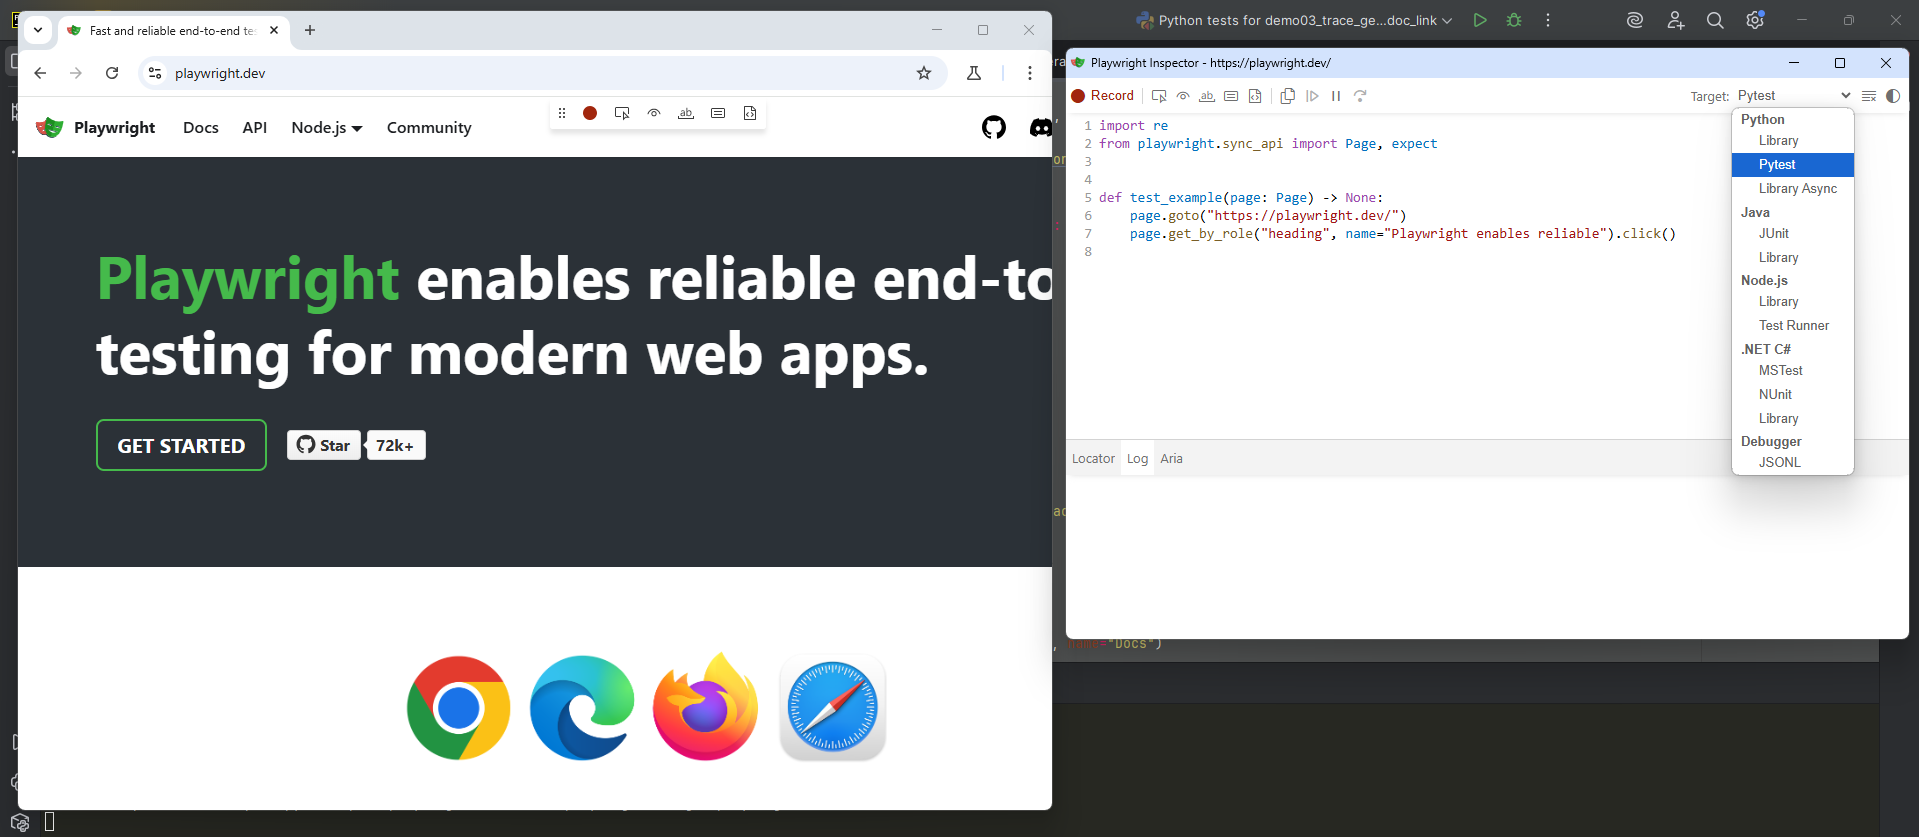